In [2]:
import pandas as pd
import numpy as np
import datetime as dt
import openpyxl
import matplotlib.pyplot as plt

In [3]:
filepath_Luzern_weather_2025 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_recent.csv"
df_Luzern_weather_2025 = pd.read_csv(filepath_Luzern_weather_2025, sep=';')

filepath_Luzern_weather_until2024 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_historical.csv" 
df_Luzern_weather_until2024 = pd.read_csv(filepath_Luzern_weather_until2024, sep=';')

df_Luzern_weather = pd.concat([df_Luzern_weather_until2024, df_Luzern_weather_2025], axis=0, ignore_index=True)
display(df_Luzern_weather)

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,13.07.1880 00:00,17.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LUZ,14.07.1880 00:00,18.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LUZ,15.07.1880 00:00,20.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LUZ,16.07.1880 00:00,22.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LUZ,17.07.1880 00:00,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53091,LUZ,21.11.2025 00:00,-0.2,1.0,-1.0,-0.8,0.3,-1.9,86.8,5.2,...,0.0,0.4,0.0,310.0,20.2,12.2,4.0,NaN,NaN,NaN
53092,LUZ,22.11.2025 00:00,-2.2,0.0,-5.8,-4.0,1.2,-10.2,77.9,4.0,...,2.0,0.4,0.0,302.0,22.2,14.2,-0.1,NaN,NaN,NaN
53093,LUZ,23.11.2025 00:00,-2.4,1.1,-7.3,-3.9,0.9,-11.3,80.0,4.2,...,34.0,0.2,0.0,270.0,22.4,14.4,1.3,NaN,NaN,NaN
53094,LUZ,24.11.2025 00:00,3.1,5.0,0.5,2.6,4.8,0.1,96.8,7.4,...,0.0,0.3,0.0,214.0,16.9,8.9,29.1,NaN,NaN,NaN


In [4]:
filepath_Luzern_weather_2025 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_recent.csv"
df_Luzern_weather_2025 = pd.read_csv(filepath_Luzern_weather_2025, sep=';')
display(df_Luzern_weather_2025)

filepath_Luzern_weather_until2024 = "https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/luz/ogd-smn_luz_d_historical.csv" 
df_Luzern_weather_until2024 = pd.read_csv(filepath_Luzern_weather_until2024, sep=';')
display(df_Luzern_weather_until2024)

df_Luzern_weather = pd.concat([df_Luzern_weather_until2024 , df_Luzern_weather_2025], axis=0, ignore_index=True)

# convert timestamp column to datetime
df_Luzern_weather["reference_timestamp"] = pd.to_datetime(
    df_Luzern_weather["reference_timestamp"], dayfirst=True)

# define date range
start_date = pd.Timestamp("2020-01-01")
end_date = pd.Timestamp(dt.datetime.today().date())

# filter
df_weather_filtered = df_Luzern_weather[(df_Luzern_weather["reference_timestamp"] >= start_date) & (df_Luzern_weather["reference_timestamp"] <= end_date)]

#select columns with relevant data
selected_columns_weather = ["reference_timestamp","rka150d0","rre150d0","sre000d0","tre200d0",]

df_weather_final = df_weather_filtered[selected_columns_weather]

df_weather_final

df_weather_final = df_weather_final.rename(columns={
    "reference_timestamp": "Datum", "rka150d0": "Niederschlag Tagessumme 0 UTC", "rre150d0": "Niederschlag Tagessumme 6 UTC", "sre000d0": "Sonnenscheindauer Tagessumme", "tre200d0": "Lufttemperatur 2m Tagesmittel"})

df_weather_final = df_weather_final.reset_index(drop=True)
df_weather_final

,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,01.01.2025 00:00,-1.2,3.7,-3.5,-1.9,7.7,-6.3,91.6,5.1,...,68,0.1,0.0,217,21.2,13.2,-0.1,NaN,NaN,NaN
1,LUZ,02.01.2025 00:00,2.0,8.8,-2.7,0.6,6.7,-6.2,86.0,6.1,...,5,0.5,0.0,297,18.0,10.0,20.5,NaN,NaN,NaN
2,LUZ,03.01.2025 00:00,0.5,1.3,-1.0,-0.6,2.1,-4.6,89.0,5.6,...,1,0.3,0.0,354,19.5,11.5,0.3,NaN,NaN,NaN
3,LUZ,04.01.2025 00:00,-1.0,0.2,-2.3,-1.0,5.1,-3.9,80.3,4.6,...,14,0.2,0.0,329,21.0,13.0,3.3,NaN,NaN,NaN
4,LUZ,05.01.2025 00:00,2.9,7.7,0.0,1.9,12.4,-1.9,93.0,7.0,...,23,0.2,0.0,225,17.1,9.1,4.8,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
324,LUZ,21.11.2025 00:00,-0.2,1.0,-1.0,-0.8,0.3,-1.9,86.8,5.2,...,0,0.4,0.0,310,20.2,12.2,4.0,NaN,NaN,NaN
325,LUZ,22.11.2025 00:00,-2.2,0.0,-5.8,-4.0,1.2,-10.2,77.9,4.0,...,2,0.4,0.0,302,22.2,14.2,-0.1,NaN,NaN,NaN
326,LUZ,23.11.2025 00:00,-2.4,1.1,-7.3,-3.9,0.9,-11.3,80.0,4.2,...,34,0.2,0.0,270,22.4,14.4,1.3,NaN,NaN,NaN
327,LUZ,24.11.2025 00:00,3.1,5.0,0.5,2.6,4.8,0.1,96.8,7.4,...,0,0.3,0.0,214,16.9,8.9,29.1,NaN,NaN,NaN


,station_abbr,reference_timestamp,tre200d0,tre200dx,tre200dn,tre005d0,tre005dx,tre005dn,ure200d0,pva200d0,...,sremaxdv,erefaod0,xcd000d0,dkl010d0,xno000d0,xno012d0,rreetsd0,tso005d0,tso010d0,tso020d0
0,LUZ,13.07.1880 00:00,17.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LUZ,14.07.1880 00:00,18.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LUZ,15.07.1880 00:00,20.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LUZ,16.07.1880 00:00,22.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LUZ,17.07.1880 00:00,23.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52762,LUZ,27.12.2024 00:00,-1.1,-0.4,-2.1,-0.5,2.0,-1.7,91.8,5.2,...,0.0,0.3,0.0,315.0,21.1,13.1,0.0,NaN,NaN,NaN
52763,LUZ,28.12.2024 00:00,-1.4,0.0,-2.9,-0.8,1.8,-2.3,94.4,5.2,...,0.0,0.2,0.0,288.0,21.4,13.4,0.0,NaN,NaN,NaN
52764,LUZ,29.12.2024 00:00,-1.3,1.3,-2.8,-0.1,7.3,-2.1,93.2,5.2,...,41.0,0.1,0.0,270.0,21.3,13.3,-0.1,NaN,NaN,NaN
52765,LUZ,30.12.2024 00:00,-1.8,-0.2,-3.0,-1.0,0.9,-2.2,94.6,5.1,...,0.0,0.3,0.0,333.0,21.8,13.8,0.0,NaN,NaN,NaN


,Datum,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel
0,2020-01-01,0.0,0.0,0.0,0.0
1,2020-01-02,0.0,0.0,0.0,-0.5
2,2020-01-03,2.9,3.0,102.0,2.0
3,2020-01-04,0.1,0.0,13.0,5.1
4,2020-01-05,0.0,0.0,392.0,1.9
...,...,...,...,...,...
2151,2025-11-21,4.1,1.8,0.0,-0.2
2152,2025-11-22,0.0,0.0,8.0,-2.2
2153,2025-11-23,1.6,10.1,148.0,-2.4
2154,2025-11-24,29.1,20.8,0.0,3.1


In [5]:

filepath_Births_Switzerland_100years = "data/px-x-0102020204_111.csv"
df_Births = pd.read_csv(filepath_Births_Switzerland_100years, sep=';', encoding='latin1')
display(df_Births)

# select only month columns (all except "Jahr")
month_cols = [c for c in df_Births.columns if c != "Jahr"]

# calculate average per month over all years
avg = df_Births[month_cols].mean()

# turn into a DataFrame and clean it up
avg_birthdays = avg.reset_index()
avg_birthdays.columns = ["month", "average number of births (100 year avg)"]

# optional: remove the German prefix from the month names
avg_birthdays["month"] = avg_birthdays["month"].str.replace("Lebendgeburten im ", "", regex=False)
avg_birthdays

,Jahr,Lebendgeburten im Januar,Lebendgeburten im Februar,Lebendgeburten im März,Lebendgeburten im April,Lebendgeburten im Mai,Lebendgeburten im Juni,Lebendgeburten im Juli,Lebendgeburten im August,Lebendgeburten im September,Lebendgeburten im Oktober,Lebendgeburten im November,Lebendgeburten im Dezember
0,1925,6004,6152,6766,6336,6477,6069,6122,6198,5716,5761,5365,5604
1,1926,5917,5833,6901,6271,6350,6096,6145,5925,5891,5597,5408,5784
2,1927,6190,5769,6481,6200,6256,5934,5973,5731,5281,4888,5080,5750
3,1928,5970,6145,6342,6038,6129,5787,5998,5693,5436,5397,5176,5483
4,1929,5810,5818,6382,5993,6258,5608,5860,5739,5548,5422,5173,5395
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2020,7108,6738,7071,7060,7369,7324,7810,7375,7440,7250,6494,6875
96,2021,7439,6876,7536,7269,7449,7428,7957,7831,7874,7842,7165,6978
97,2022,6933,6072,6679,6738,7064,7145,7428,7313,7115,6909,6422,6553
98,2023,6524,6059,6691,6424,7044,6994,7081,6901,6736,6823,6428,6319


,month,average number of births (100 year avg)
0,Januar,6852.12
1,Februar,6590.24
2,März,7288.88
3,April,7048.37
4,Mai,7211.93
5,Juni,6877.36
6,Juli,7076.14
7,August,6840.05
8,September,6763.88
9,Oktober,6589.36


In [6]:
filepath_Feiertage_Schweiz_2025 = "data/Feiertage_Schweiz_2025.csv"
df_public_holidays = pd.read_csv(filepath_Feiertage_Schweiz_2025, sep=',', encoding='latin1')

df_public_holidays.drop(columns=["Unnamed: 1"], inplace=True)
df_public_holidays.rename(columns={"2025" : "Datum", "Unnamed: 2" : "Feiertag"}, inplace=True)
display(df_public_holidays)

,Datum,Feiertag
0,01.01.2025,Neujahr
1,02.01.2025,Berchtoldstag
2,06.01.2025,Heilige Drei Könige (München und Stuttgart ges...
3,18.04.2025,Karfreitag
4,21.04.2025,Ostermontag
5,01.05.2025,Internationaler Tag der Arbeit
6,08.05.2025,80. Jahrestag der Befreiung vom Nationalsozial...
7,29.05.2025,Auffahrt
8,09.06.2025,Pfingstmontag
9,19.06.2025,"Fronleichnam (München, Frankfurt und Stuttgart..."


In [7]:
filepath_Feiertage_Ferien_LU_2024_25 = "data/fcal_Luzern_2024.csv"
df_public_holidays_LU = pd.read_csv(filepath_Feiertage_Ferien_LU_2024_25, sep=';')

df_public_holidays_LU['Bezeichnung'] = df_public_holidays_LU['Bezeichnung'].str.replace('�', 'ü')
df_public_holidays_LU["Datum"] = pd.to_datetime(df_public_holidays_LU["Datum"], dayfirst=True)
df_public_holidays_LU["Ende"] = pd.to_datetime(df_public_holidays_LU["Ende"], dayfirst=True)
df_public_holidays_LU = df_public_holidays_LU[df_public_holidays_LU["Datum"] <= pd.Timestamp(dt.datetime.today().date())]
df_public_holidays_LU.drop(columns=["Bemerkungen","Unnamed: 4"], inplace=True)

display(df_public_holidays_LU)

,Datum,Ende,Bezeichnung
0,2023-12-23,2024-01-07,Weihnachtsferien
1,2024-02-03,2024-02-18,Fasnachtsferien
2,2024-03-29,2024-04-14,Frühlingsferien
3,2024-05-09,2024-05-12,Auffahrtsferien
4,2024-05-20,2024-05-20,Pfingstmontag
5,2024-05-30,2024-06-02,Fronleichnam
6,2024-07-06,2024-08-18,Sommerferien
7,2024-09-28,2024-10-13,Herbstferien
8,2024-11-01,2024-11-01,Allerheiligen
9,2024-12-21,2025-01-05,Weihnachtsferien


In [8]:
# Pfad zur Excel-Datei
file_path = "data/SON Tagesumsätze 2021.xlsx"

# Monatsnamen oder Sheetnamen
sheets = ["01_21", "02_21", "03_21", "04_21", "05_21", "06_21",
          "07_21", "08_21", "09_21", "10_21", "11_21", "12_21"]

# Liste für alle Monats-DataFrames
all_data = []

for sheet in sheets:
    # Sheet einlesen, Header überspringen (skiprows=2)
    df = pd.read_excel(file_path, sheet_name=sheet, skiprows=2)

    # Nur die relevanten Spalten auswählen
    df = df[['Unnamed: 1', 'Restaurant', 'Terrasse']]  # Index-Spalte als Tag
    
    # Spalten umbenennen
    df.columns = ['Tag', 'Restaurant', 'Terrasse']
    
    # Nur Zeilen behalten, die echte Tage enthalten (Fr, Sa, So, Mo, Di, Mi, Do)
    df = df[df['Tag'].isin(['Mo','Di','Mi','Do','Fr','Sa','So'])]
    
    # Monat hinzufügen, um spätere Datumsspalte zu erstellen
    df['Monat'] = sheet
    
    all_data.append(df)

# Alle Monate zusammenführen
final_df = pd.concat(all_data, ignore_index=True)


# Funktion zum Bereinigen und Konvertieren
def to_float(x):
    if pd.isna(x):
        return 0.0
    # alle Sonderzeichen entfernen, z.B. '1’620.20' -> '1620.20'
    x = str(x).replace("’","").replace(",",".")
    return float(x)

# Spalten konvertieren
final_df['Restaurant'] = final_df['Restaurant'].apply(to_float)
final_df['Terrasse'] = final_df['Terrasse'].apply(to_float)


month_map = {
    '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6,
    '07': 7, '08': 8, '09': 9, '10': 10, '11': 11, '12': 12
}

for month_id, month_number in month_map.items():
    # nur Zeilen für diesen Monat
    mask = final_df['Monat'].str.startswith(month_id)
    month_rows = final_df[mask].copy()
    
    # Tag-Nummer hochzählen
    month_rows['Datum'] = [pd.Timestamp(year=2025, month=month_number, day=i+1) for i in range(len(month_rows))]
    
    # zurück ins finale DataFrame
    final_df.loc[mask, 'Datum'] = month_rows['Datum']

final_df.drop(columns=["Monat"],inplace=True)

display(final_df)

,Tag,Restaurant,Terrasse,Datum
0,Fr,1620.2,0.0,2025-01-01
1,Sa,872.9,0.0,2025-01-02
2,So,0.0,0.0,2025-01-03
3,Mo,636.2,0.0,2025-01-04
4,Di,694.5,0.0,2025-01-05
...,...,...,...,...
360,Mo,2173.4,0.0,2025-12-27
361,Di,5036.8,0.0,2025-12-28
362,Mi,3676.0,0.0,2025-12-29
363,Do,5566.3,123.5,2025-12-30


,Tag,Restaurant,Terrasse,Datum
0,Fr,1620.2,0.0,2021-01-01
1,Sa,872.9,0.0,2021-01-02
2,So,0.0,0.0,2021-01-03
3,Mo,636.2,0.0,2021-01-04
4,Di,694.5,0.0,2021-01-05
...,...,...,...,...
1722,Mi,6279.9,362.6,2025-11-12
1723,Do,6735.1,307.4,2025-11-13
1724,Fr,12458.5,80.0,2025-11-14
1725,Sa,15362.0,1909.4,2025-11-15


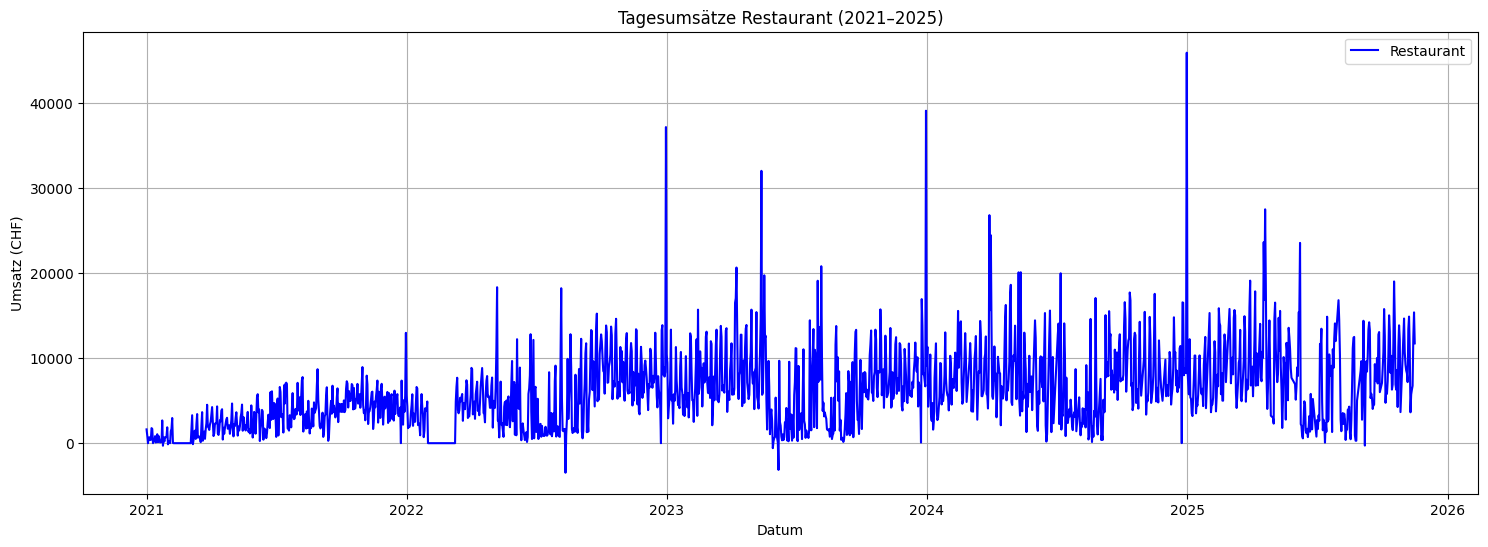

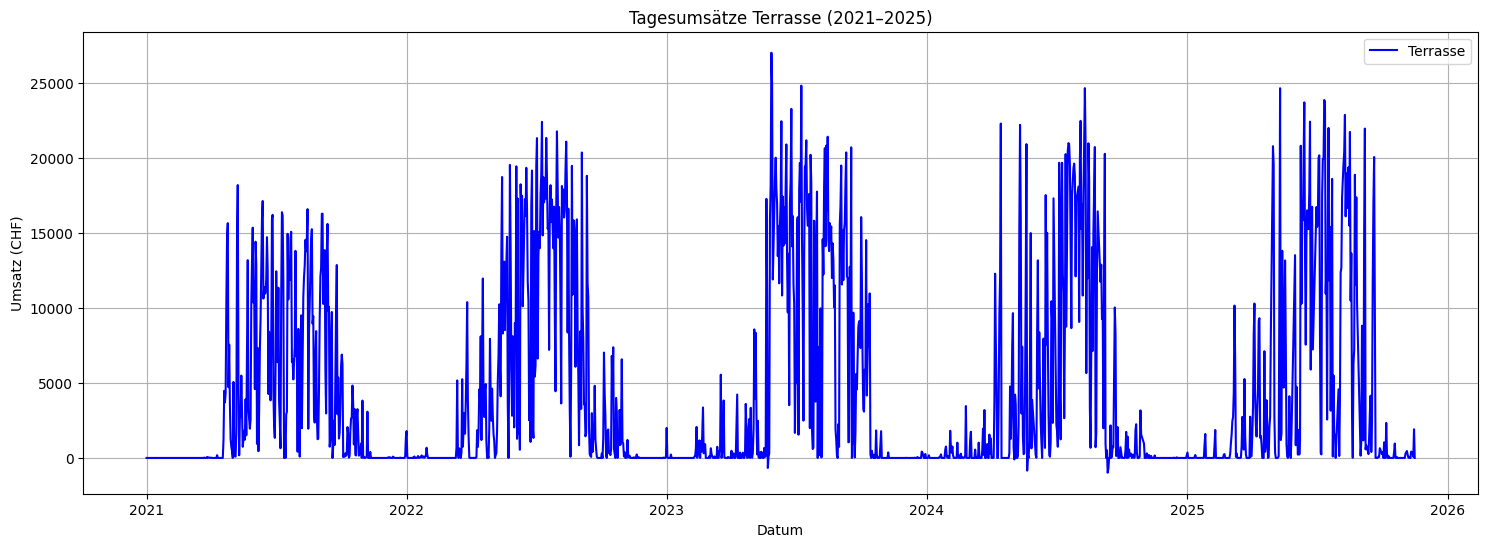

In [9]:
# Basis Pfad zur Excel-Datei
file_path_template = "data/SON Tagesumsätze {year}.xlsx"

# Jahre, die wir einlesen wollen
years = [2021, 2022, 2023, 2024, 2025]

# Mapping für Monat aus Sheetname
month_map = {
    '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6,
    '07': 7, '08': 8, '09': 9, '10': 10, '11': 11, '12': 12
}

# Liste für alle DataFrames
all_data = []

# Funktion zum Bereinigen und Konvertieren
def to_float(x):
    if pd.isna(x):
        return 0.0
    x = str(x).replace("’","").replace(",",".")
    return float(x)

# Echte Tageszeilen
tage = ['Mo','Di','Mi','Do','Fr','Sa','So']

for year in years:
    file_path = file_path_template.format(year=year)
    
    # Monatsnamen/Sheets für das Jahr
    sheets = [f"{str(i).zfill(2)}_{str(year)[-2:]}" for i in range(1,13)]
    
    for sheet in sheets:
        # Sheet einlesen, Header überspringen
        df = pd.read_excel(file_path, sheet_name=sheet, skiprows=2)
        
        # Relevante Spalten
        df = df[['Unnamed: 1', 'Restaurant', 'Terrasse']]
        df.columns = ['Tag', 'Restaurant', 'Terrasse']
        
        # Nur echte Tage
        df = df[df['Tag'].isin(tage)]
        
        # Jahr + Monat hinzufügen
        df['Jahr'] = year
        df['Monat'] = sheet
        
        # Restaurant/Terrasse konvertieren
        df['Restaurant'] = df['Restaurant'].apply(to_float)
        df['Terrasse'] = df['Terrasse'].apply(to_float)
        
        # Tag hochzählen
        month_id = sheet.split("_")[0]
        month_number = month_map[month_id]
        df['Datum'] = [pd.Timestamp(year=year, month=month_number, day=i+1) for i in range(len(df))]
        
        # Append
        all_data.append(df)

# Alles zusammenführen
final_df = pd.concat(all_data, ignore_index=True)

# Überflüssige Spalten löschen
final_df.drop(columns=['Jahr','Monat'], inplace=True)
final_df = final_df[final_df["Datum"] < pd.to_datetime("2025-11-17")]

# Ergebnis anzeigen
pd.set_option("display.max_rows",50)
display(final_df)


# Datum als Index setzen für einfaches Plotten
final_df = final_df.sort_values('Datum')  # sicherstellen, dass die Daten chronologisch sind
final_df.set_index('Datum', inplace=True)


# Restaurant Umsatz
plt.figure(figsize=(18,6))
plt.plot(final_df.index, final_df['Restaurant'], label='Restaurant', color='blue')
plt.title("Tagesumsätze Restaurant (2021–2025)")
plt.xlabel("Datum")
plt.ylabel("Umsatz (CHF)")
plt.legend()
plt.grid(True)
plt.show()

# Terrasse Umsatz
plt.figure(figsize=(18,6))
plt.plot(final_df.index, final_df['Terrasse'], label='Terrasse', color='blue')
plt.title("Tagesumsätze Terrasse (2021–2025)")
plt.xlabel("Datum")
plt.ylabel("Umsatz (CHF)")
plt.legend()
plt.grid(True)
plt.show()


In [10]:
filepath_GDP = "data/snb-data-gdpap-de-selection-20251121_0900.csv"
df_GDP = pd.read_csv(filepath_GDP, sep=";", header=2)
df_GDP = df_GDP[df_GDP["D0"] == "VVP"]
df_GDP.drop(columns=["D0","D1"],inplace=True)
display(df_GDP)

,Date,Value
1,2021-Q1,1.070853
3,2021-Q2,3.511144
5,2021-Q3,2.558028
7,2021-Q4,1.581198
9,2022-Q1,1.549760
11,2022-Q2,1.296646
13,2022-Q3,1.010062
15,2022-Q4,0.581978
17,2023-Q1,0.988351
19,2023-Q2,-0.428013


In [11]:
#Hinzufügen eines Wochenendbonus
final_df["is_fr_sa"] = final_df["Tag"].isin(["Fr", "Sa"]).astype(int)
final_df

,Tag,Restaurant,Terrasse,is_fr_sa
Datum,,,,
2021-01-01,Fr,1620.2,0.0,1
2021-01-02,Sa,872.9,0.0,1
2021-01-03,So,0.0,0.0,0
2021-01-04,Mo,636.2,0.0,0
2021-01-05,Di,694.5,0.0,0
...,...,...,...,...
2025-11-12,Mi,6279.9,362.6,0
2025-11-13,Do,6735.1,307.4,0
2025-11-14,Fr,12458.5,80.0,1


# Merging

In [12]:
file_path_special_events = "data/Special_Events.xlsx"

sheets = ["2021", "2022", "2023", "2024", "2025"]

df_list = []
for sheet in sheets:
    df = pd.read_excel(
                file_path_special_events,
                sheet_name=sheet,
                usecols="A,I,L",   # A = Datum, I = Wert\
                header=None,
                skiprows=2)       # skip first two header rows\n",
    
    df.columns = ["Datum", "Ferien-Value", "Special-Day-Value"]

    df_list.append(df)
    
df_special_events = pd.concat(df_list, ignore_index=True)
df_special_events.fillna(0.0, inplace=True)
display(df_special_events)

,Datum,Ferien-Value,Special-Day-Value
0,2021-01-01,1.0,1.0
1,2021-01-02,1.0,0.0
2,2021-01-03,1.0,0.0
3,2021-01-04,1.0,0.0
4,2021-01-05,1.0,0.0
...,...,...,...
1760,2025-10-27,0.0,0.0
1761,2025-10-28,0.0,0.0
1762,2025-10-29,0.0,0.0
1763,2025-10-30,0.0,0.0


In [13]:
df_merged = pd.merge(final_df, df_special_events, on="Datum", how="left")
display(df_merged.head())

df_merged.to_csv("data/dataset-merged.csv", index=False)

,Datum,Tag,Restaurant,Terrasse,is_fr_sa,Ferien-Value,Special-Day-Value
0,2021-01-01,Fr,1620.2,0.0,1,1.0,1.0
1,2021-01-02,Sa,872.9,0.0,1,1.0,0.0
2,2021-01-03,So,0.0,0.0,0,1.0,0.0
3,2021-01-04,Mo,636.2,0.0,0,1.0,0.0
4,2021-01-05,Di,694.5,0.0,0,1.0,0.0


In [14]:
display(avg_birthdays)

df_merged_1 = pd.merge(df_merged, df_weather_final, on="Datum", how="left")



,month,average number of births (100 year avg)
0,Januar,6852.12
1,Februar,6590.24
2,März,7288.88
3,April,7048.37
4,Mai,7211.93
5,Juni,6877.36
6,Juli,7076.14
7,August,6840.05
8,September,6763.88
9,Oktober,6589.36


In [15]:
df_merged_1['month'] = df_merged_1['Datum'].dt.month_name(locale='de_DE')
df_merged_1.head()

,Datum,Tag,Restaurant,Terrasse,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,month
0,2021-01-01,Fr,1620.2,0.0,1,1.0,1.0,0.6,0.6,0.0,1.7,Januar
1,2021-01-02,Sa,872.9,0.0,1,1.0,0.0,0.0,0.0,0.0,1.5,Januar
2,2021-01-03,So,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.5,Januar
3,2021-01-04,Mo,636.2,0.0,0,1.0,0.0,0.0,0.0,0.0,0.1,Januar
4,2021-01-05,Di,694.5,0.0,0,1.0,0.0,0.0,0.0,0.0,-0.2,Januar


In [16]:
df_merged_2 = pd.merge(df_merged_1, avg_birthdays, on="month", how="left")

In [17]:
df_merged_2 = df_merged_2.rename(columns={"month": "Monat", 
                                          "average number of births (100 year avg)": "Durchschnittliche Anzahl Geburtstage (über 100 Jahre)"
                                          })

df_merged_2# Liste aller Spalten holen
cols = list(df_merged_2.columns)

# "Monat" direkt hinter "Datum" schieben
cols.insert(cols.index("Datum") + 1, cols.pop(cols.index("Monat")))

# DataFrame neu anordnen
df_merged_2 = df_merged_2[cols]


display(df_merged_2)

df_merged_2.to_csv("data/dataset-merged-2.csv", index=False)

,Datum,Monat,Tag,Restaurant,Terrasse,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 0 UTC,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre)
0,2021-01-01,Januar,Fr,1620.2,0.0,1,1.0,1.0,0.6,0.6,0.0,1.7,6852.12
1,2021-01-02,Januar,Sa,872.9,0.0,1,1.0,0.0,0.0,0.0,0.0,1.5,6852.12
2,2021-01-03,Januar,So,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0,0.5,6852.12
3,2021-01-04,Januar,Mo,636.2,0.0,0,1.0,0.0,0.0,0.0,0.0,0.1,6852.12
4,2021-01-05,Januar,Di,694.5,0.0,0,1.0,0.0,0.0,0.0,0.0,-0.2,6852.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,2025-11-12,November,Mi,6279.9,362.6,0,NaN,NaN,0.0,0.0,419.0,6.2,6225.59
1723,2025-11-13,November,Do,6735.1,307.4,0,NaN,NaN,0.0,0.0,426.0,8.1,6225.59
1724,2025-11-14,November,Fr,12458.5,80.0,1,NaN,NaN,0.0,0.0,113.0,9.2,6225.59
1725,2025-11-15,November,Sa,15362.0,1909.4,1,NaN,NaN,0.0,0.0,396.0,12.0,6225.59


Cleaning

In [18]:
df_merged_2.isna().sum()

Datum                                                     0
Monat                                                     0
Tag                                                       0
Restaurant                                                0
Terrasse                                                  0
is_fr_sa                                                  0
Ferien-Value                                             16
Special-Day-Value                                        16
Niederschlag Tagessumme 0 UTC                             3
Niederschlag Tagessumme 6 UTC                             0
Sonnenscheindauer Tagessumme                              0
Lufttemperatur 2m Tagesmittel                             0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)     0
dtype: int64

In [19]:
#Werte NaN bei Special-Day-Values und Ferien_Value auffüllen mit 0
df_merged_2["Ferien-Value"] = df_merged_2["Ferien-Value"].fillna(0)
df_merged_2["Special-Day-Value"] = df_merged_2["Special-Day-Value"].fillna(0)

#Niederschlag Tagessumme 0 UTC löschen
df_merged_2 = df_merged_2.drop(columns=["Niederschlag Tagessumme 0 UTC"])

#Umbenennen der Spalte Restaurant
df_merged_2.rename(columns={"Restaurant": "Tagesumsatz Restaurant"})

,Datum,Monat,Tag,Tagesumsatz Restaurant,Terrasse,is_fr_sa,Ferien-Value,Special-Day-Value,Niederschlag Tagessumme 6 UTC,Sonnenscheindauer Tagessumme,Lufttemperatur 2m Tagesmittel,Durchschnittliche Anzahl Geburtstage (über 100 Jahre)
0,2021-01-01,Januar,Fr,1620.2,0.0,1,1.0,1.0,0.6,0.0,1.7,6852.12
1,2021-01-02,Januar,Sa,872.9,0.0,1,1.0,0.0,0.0,0.0,1.5,6852.12
2,2021-01-03,Januar,So,0.0,0.0,0,1.0,0.0,0.0,0.0,0.5,6852.12
3,2021-01-04,Januar,Mo,636.2,0.0,0,1.0,0.0,0.0,0.0,0.1,6852.12
4,2021-01-05,Januar,Di,694.5,0.0,0,1.0,0.0,0.0,0.0,-0.2,6852.12
...,...,...,...,...,...,...,...,...,...,...,...,...
1722,2025-11-12,November,Mi,6279.9,362.6,0,0.0,0.0,0.0,419.0,6.2,6225.59
1723,2025-11-13,November,Do,6735.1,307.4,0,0.0,0.0,0.0,426.0,8.1,6225.59
1724,2025-11-14,November,Fr,12458.5,80.0,1,0.0,0.0,0.0,113.0,9.2,6225.59
1725,2025-11-15,November,Sa,15362.0,1909.4,1,0.0,0.0,0.0,396.0,12.0,6225.59


In [20]:
df_merged_2.isna().sum()

Datum                                                    0
Monat                                                    0
Tag                                                      0
Restaurant                                               0
Terrasse                                                 0
is_fr_sa                                                 0
Ferien-Value                                             0
Special-Day-Value                                        0
Niederschlag Tagessumme 6 UTC                            0
Sonnenscheindauer Tagessumme                             0
Lufttemperatur 2m Tagesmittel                            0
Durchschnittliche Anzahl Geburtstage (über 100 Jahre)    0
dtype: int64

In [22]:
#negative Umsätze rausnehmen
import pandas as pd

# Datum als Datetime
df_merged_2["Datum"] = pd.to_datetime(df_merged_2["Datum"])

col_umsatz = "Restaurant"

# nach Datum sortieren
df_merged_2 = df_merged_2.sort_values("Datum").reset_index(drop=True)

# Maske für negative Umsätze
neg_mask = df_merged_2[col_umsatz] < 0

print("Anzahl negativer Umsätze vorher:", neg_mask.sum())

for idx in df_merged_2[neg_mask].index:
    current_date = df_merged_2.at[idx, "Datum"]
    weekday = current_date.weekday()              # 0=Mo, ..., 6=So
    start_date = current_date - pd.Timedelta(weeks=4)

    # gleiche Wochentage der letzten 4 Wochen, nur positive Umsätze
    hist = df_merged_2[
        (df_merged_2["Datum"] < current_date) &
        (df_merged_2["Datum"] >= start_date) &
        (df_merged_2["Datum"].dt.weekday == weekday) &
        (df_merged_2[col_umsatz] >= 0)
    ]

    # Fallback 1: gleicher Wochentag über gesamte Vergangenheit
    if hist.empty:
        hist = df_merged_2[
            (df_merged_2["Datum"] < current_date) &
            (df_merged_2["Datum"].dt.weekday == weekday) &
            (df_merged_2[col_umsatz] >= 0)
        ]

    # Fallback 2: globaler Mittelwert aller nicht-negativen Umsätze
    if hist.empty:
        replacement = df_merged_2.loc[df_merged_2[col_umsatz] >= 0, col_umsatz].mean()
    else:
        replacement = hist[col_umsatz].mean()

    df_merged_2.at[idx, col_umsatz] = replacement

# Kontrolle
print("Anzahl negativer Umsätze nachher:", (df_merged_2[col_umsatz] < 0).sum())


Anzahl negativer Umsätze vorher: 7
Anzahl negativer Umsätze nachher: 0


In [ ]:
df_merged_2.to_csv("data/dataset-merged-2.csv", index=False)